In [316]:
import numpy as np
import matplotlib.pyplot as plt
import lightkurve as lk

In [317]:
name = "TOI-1181"
mission = "TESS"
author = "SPOC"
exp_time = 120

In [318]:
tpf_search = lk.search_targetpixelfile(name, mission=mission, author=author, exptime=exp_time, sector = 73)
lc_search = lk.search_lightcurve(name, mission=mission, author=author, exptime=exp_time, sector = 73)

print(tpf_search)
print(lc_search)

SearchResult containing 1 data products.

 #     mission     year author exptime target_name distance
                                  s                 arcsec 
--- -------------- ---- ------ ------- ----------- --------
  0 TESS Sector 73 2023   SPOC     120   229510866      0.0
SearchResult containing 1 data products.

 #     mission     year author exptime target_name distance
                                  s                 arcsec 
--- -------------- ---- ------ ------- ----------- --------
  0 TESS Sector 73 2023   SPOC     120   229510866      0.0


In [320]:
tpf_downloaded = tpf_search[:5].download_all()
lc_downloaded = lc_search[:5].download_all()

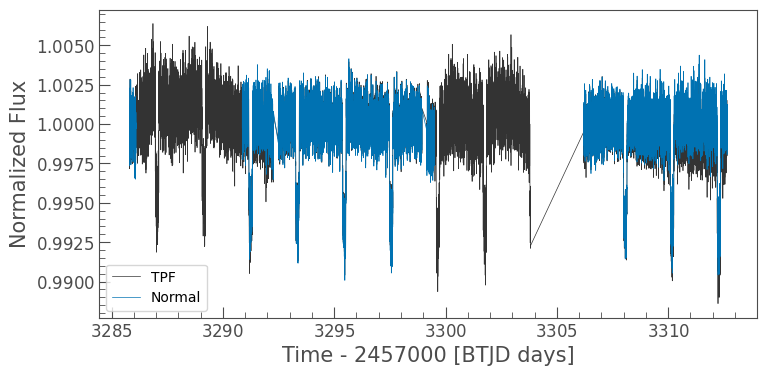

In [321]:
tpf_lightcurves = []
for tpf in tpf_downloaded:
    aperture_mask = tpf.pipeline_mask
    lc = tpf.to_lightcurve(aperture_mask=aperture_mask)
    tpf_lightcurves.append(lc)

tpf_lightcurves = lk.LightCurveCollection(tpf_lightcurves)

stiched_tpf_lc = tpf_lightcurves.stitch()
stiched_normal_lc = lc_downloaded.stitch()

ax = stiched_tpf_lc.plot(label="TPF")
stiched_normal_lc.plot(ax=ax, label="Normal")

plt.legend()
plt.show()




In [322]:
# now phase fold and compare

period = 2.103189

folded_tpf_lc = stiched_tpf_lc.fold(period=period)
folded_normal_lc = stiched_normal_lc.fold(period=period)
binned_tpf_lc = folded_tpf_lc.remove_outliers().bin(binsize=10)
binned_normal_lc = folded_normal_lc.bin(binsize=10)

# ax = folded_tpf_lc.remove_outliers().bin(binsize=10).plot(label="TPF")
# folded_normal_lc.bin(binsize=10).plot(ax=ax, label="Normal")
# plt.xlim(-0.2,0.05)
# plt.legend()
# plt.show()

/var/folders/c0/vw8qk1r12ls3wbl2nq_z5cx00000gn/T/ipykernel_5338/2705707200.py:7: LightkurveDeprecationWarning: "binsize" was deprecated in version 2.0 and will be removed in a future version. 
        Use time_bin_size instead.
  binned_tpf_lc = folded_tpf_lc.remove_outliers().bin(binsize=10)
/var/folders/c0/vw8qk1r12ls3wbl2nq_z5cx00000gn/T/ipykernel_5338/2705707200.py:8: LightkurveDeprecationWarning: "binsize" was deprecated in version 2.0 and will be removed in a future version. 
        Use time_bin_size instead.
  binned_normal_lc = folded_normal_lc.bin(binsize=10)


In [323]:
import sys
import os

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))
from sim.SimulateAndFlux import flux_data_from_params
from real_data_analysis import extend_params_for_stellar


radius_toi_1181 =   1.961 * 696.34e6 / 1.496e11
mass_toi_1181 = 	1.19 * 2e30 / 6e24
limb_darkening_model = 2
limb_darkening_coefficients = [0.119, 0.156]

stellar_params = [
    radius_toi_1181,
    mass_toi_1181,
    limb_darkening_model,
    limb_darkening_coefficients[0],
    limb_darkening_coefficients[1],
]  # Based on WASP 148

true_vals = np.atleast_2d(
    np.array(
        [
            [
                0.07947,
                0.035052416,
                2.103195,
                0.0011,
                np.radians(88.96862026914545),
                0,
                0,
                0,
                0,
            ],
        ]
    )
    )

true_vals = extend_params_for_stellar(true_vals, stellar_params)


radius_toi_1181 =   1.7 * 696.34e6 / 1.496e11
mass_toi_1181 = 	1.19 * 2e30 / 6e24
limb_darkening_model = 2
limb_darkening_coefficients = [0.119, 0.156]

stellar_params_big_star = [
    radius_toi_1181,
    mass_toi_1181,
    limb_darkening_model,
    limb_darkening_coefficients[0],
    limb_darkening_coefficients[1],
]  # Based on WASP 148

true_vals_with_big_star = extend_params_for_stellar(true_vals, stellar_params_big_star)


our_vals = np.atleast_2d(
    np.array(
        [
            [
                7.8e-02,
                3.44e-02,
                2.103e+00,
                0.0011,
                1.43e+00,
                -3.48e-1, #9.321e-01,
                0,
                2.28e-02,
                0

            ]
        ]
    )
)

our_vals = extend_params_for_stellar(our_vals, stellar_params)



true_fluxes = flux_data_from_params(true_vals, stiched_normal_lc.time.value, no_loading_bar=True, analytical_bool=True, batman_bool=True)
true_folded_times = stiched_normal_lc.time.value % period - 1

our_fluxes = flux_data_from_params(our_vals, stiched_normal_lc.time.value, no_loading_bar=True, analytical_bool=True, batman_bool=True)
our_folded_times = stiched_normal_lc.time.value % 2.103e+00 - 1

our_fluxes_big_star = flux_data_from_params(true_vals_with_big_star, stiched_normal_lc.time.value, no_loading_bar=True, analytical_bool=True, batman_bool=True)
our_folded_times_big_star = stiched_normal_lc.time.value % period - 1



In [326]:
def find_mid_transit(times, fluxes):
    times_output = np.where(fluxes <= 0.995)
    # find midpoint of these
    return np.mean(times[times_output])



In [327]:
# Time order folded_times

order = np.argsort(true_folded_times)
# sort the true_fluxes the same way

true_folded_times = true_folded_times[order]
sorted_true_fluxes = true_fluxes[order]

# bin to the lenght of binned_tpf_lc

binned_true_fluxes = np.zeros(len(binned_tpf_lc.flux))
binned_true_times = np.zeros(len(binned_tpf_lc.time))

order = np.argsort(our_folded_times)

our_folded_times = our_folded_times[order]
sorted_our_fluxes = our_fluxes[order]

# bin to the lenght of binned_tpf_lc

binned_our_fluxes = np.zeros(len(binned_tpf_lc.flux))
binned_our_times = np.zeros(len(binned_tpf_lc.time))


order = np.argsort(our_folded_times_big_star)

our_folded_times_big_star = our_folded_times_big_star[order]
sorted_our_fluxes_big_star = our_fluxes_big_star[order]

# bin to the lenght of binned_tpf_lc

binned_our_fluxes_big_star = np.zeros(len(binned_tpf_lc.flux))
binned_our_times_big_star = np.zeros(len(binned_tpf_lc.time))



# Now bin the actual values with lenght of 10
index = []
for i in range(len(binned_tpf_lc.flux)):
    index.append(i)
    binned_true_fluxes[i] = np.mean(sorted_true_fluxes[i*10:(i+1)*10])
    binned_true_times[i] = np.mean(true_folded_times[i*10:(i+1)*10])

    binned_our_fluxes[i] = np.mean(sorted_our_fluxes[i*10:(i+1)*10])
    binned_our_times[i] = np.mean(our_folded_times[i*10:(i+1)*10])

    binned_our_fluxes_big_star[i] = np.mean(sorted_our_fluxes_big_star[i*10:(i+1)*10])
    binned_our_times_big_star[i] = np.mean(our_folded_times_big_star[i*10:(i+1)*10])


binned_tpf_lc.time = binned_tpf_lc.time.value - find_mid_transit(binned_tpf_lc.time.value, binned_tpf_lc.flux)


binned_normal_lc.time = binned_normal_lc.time.value - find_mid_transit(binned_normal_lc.time.value, binned_normal_lc.flux)


binned_true_times = binned_true_times - find_mid_transit(binned_true_times, binned_true_fluxes)


binned_our_times = binned_our_times - find_mid_transit(binned_our_times, binned_our_fluxes)

binned_our_times_big_star = binned_our_times_big_star - find_mid_transit(binned_our_times_big_star, binned_our_fluxes_big_star)


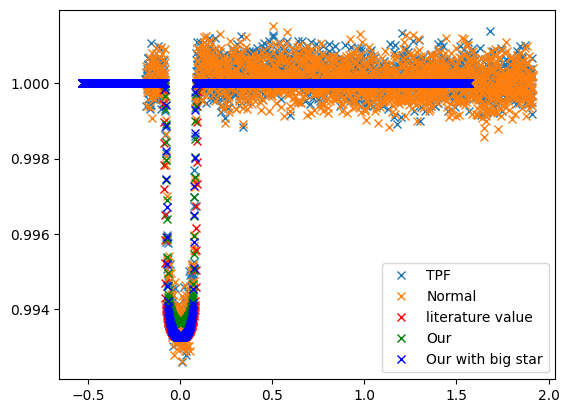

In [328]:
fig, ax = plt.subplots()

ax.plot(binned_tpf_lc.time, binned_tpf_lc.flux, "x", label="TPF")
ax.plot(binned_normal_lc.time, binned_normal_lc.flux, "x", label="Normal")
ax.plot(binned_true_times, binned_true_fluxes, "x", label="literature value", color = "r")
ax.plot(binned_our_times, binned_our_fluxes, "x", label="Our", color = "g")
ax.plot(binned_our_times_big_star, binned_our_fluxes_big_star, "x", label="Our with big star", color = "b")
plt.legend()



plt.show()

In [288]:
times = stiched_tpf_lc.time.value - stiched_tpf_lc.time.value[0]